<a href="https://colab.research.google.com/github/gurkhali/sam2/blob/Test/Sam2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Wed Apr  2 04:22:31 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
HOME = os.getcwd()
print("HOME:", HOME)

HOME: /content


In [3]:
!git clone https://github.com/facebookresearch/segment-anything-2.git
%cd {HOME}/segment-anything-2
!pip install -e . -q
!python setup.py build_ext --inplace

Cloning into 'segment-anything-2'...
remote: Enumerating objects: 1070, done.
remote: Total 1070 (delta 0), reused 0 (delta 0), pack-reused 1070 (from 1)
Receiving objects: 100% (1070/1070), 134.70 MiB | 28.61 MiB/s, done.
Resolving deltas: 100% (376/376), done.
/content/segment-anything-2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 81.5 kB/s eta 0:00:00
  Building editable for SAM-2 (pyproject.toml) ... done
running build_ext
/usr/local/lib/python3.

In [4]:
!pip install -q supervision[assets] jupyter_bbox_widget

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.7/220.7 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.5/181.5 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 765.5/765.5 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 42.8 MB/s eta 0:00:00


In [6]:
!mkdir -p {HOME}/checkpoints
!wget -q https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_tiny.pt -P {HOME}/checkpoints
!wget -q https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_small.pt -P {HOME}/checkpoints
!wget -q https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_base_plus.pt -P {HOME}/checkpoints
!wget -q https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_large.pt -P {HOME}/checkpoints

Imports

In [7]:
import cv2
import torch
import base64

import numpy as np
import supervision as sv

from pathlib import Path
from supervision.assets import download_assets, VideoAssets
from sam2.build_sam import build_sam2_video_predictor

IS_COLAB = True

if IS_COLAB:
    from google.colab import output
    output.enable_custom_widget_manager()

from jupyter_bbox_widget import BBoxWidget

In [8]:
torch.autocast(device_type="cuda", dtype=torch.bfloat16).__enter__()

if torch.cuda.get_device_properties(0).major >= 8:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

In [9]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CHECKPOINT = f"{HOME}/checkpoints/sam2_hiera_large.pt"
CONFIG = "sam2_hiera_l.yaml"

sam2_model = build_sam2_video_predictor(CONFIG, CHECKPOINT)

Download video and split it into frames
NOTE: SAM2 assumee that the video is stored as a list of JPEG frames with filenames like <frame_index>.jpg. Let's start by downloading a sample video, splitting it into frames, and saving them to disk. Feel free to replace SOURCE_VIDEO with the path to your video file.

In [100]:
SOURCE_VIDEO = "/content/sam3.mov"
sv.VideoInfo.from_video_path(SOURCE_VIDEO)

VideoInfo(width=1920, height=1080, fps=58, total_frames=120)

NOTE: To reduce VRAM requirements, we are introducing three additional parameters: SCALE_FACTOR to decrease the frame resolution, and START_IDX and END_IDX to extract only the relevant segments from the video

In [101]:
SCALE_FACTOR = 0.5
START_IDX = 0
END_IDX = 30

In [102]:
SOURCE_FRAMES = Path(HOME) / Path(SOURCE_VIDEO).stem
SOURCE_FRAMES.mkdir(parents=True, exist_ok=True)

frames_generator = sv.get_video_frames_generator(SOURCE_VIDEO, start=START_IDX, end=END_IDX)
frames_generator = sv.get_video_frames_generator(SOURCE_VIDEO, start=START_IDX)

images_sink = sv.ImageSink(
    target_dir_path=SOURCE_FRAMES.as_posix(),
    overwrite=True,
    image_name_pattern="{:05d}.jpeg"
)

with images_sink:
    for frame in frames_generator:
        frame = sv.scale_image(frame, SCALE_FACTOR)
        images_sink.save_image(frame)

TARGET_VIDEO = Path(HOME) / f"{Path(SOURCE_VIDEO).stem}-result.mp4"
SOURCE_FRAME_PATHS = sorted(sv.list_files_with_extensions(SOURCE_FRAMES.as_posix(), extensions=["jpeg"]))

Initialize the inference state
NOTE: SAM 2 requires stateful inference for interactive video segmentation, so we need to initialize an inference state on this video. During initialization, it loads all the JPEG frames in video_path and stores their pixels in inference_state (as shown in the progress bar below).

In [103]:
inference_state = sam2_model.init_state(video_path=SOURCE_FRAMES.as_posix())

frame loading (JPEG): 100%|██████████| 77/77 [00:02<00:00, 27.84it/s]


In [104]:
sam2_model.reset_state(inference_state)

Prompting with points

In [105]:
def encode_image(filepath):
    with open(filepath, 'rb') as f:
        image_bytes = f.read()
    encoded = str(base64.b64encode(image_bytes), 'utf-8')
    return "data:image/jpg;base64,"+encoded

In [115]:
OBJECTS = ['club']
OBJECTS = ['ball', 'player-1', 'player-2']

In [116]:
FRAME_IDX = 1
FRAME_PATH = Path(SOURCE_FRAMES) / f"{FRAME_IDX:05d}.jpeg"
widget = BBoxWidget(classes=OBJECTS)
widget.image = encode_image(FRAME_PATH)
widget

BBoxWidget(classes=['ball', 'player-1', 'player-2'], colors=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#946…

NOTE: The widget we are using stores annotations in a format that is inconsistent with SAM2's requirements. We parse them and then pass them to SAM2 via the add_new_points method. Each of the objects we track must be passed via a separate add_new_points call. It is important to specify frame_idx each time - the index of the frame to which the annotations relate, and obj_id - the ID of the object to which the annotations relate.

In [119]:
default_box = [
    {'x': 529, 'y': 326, 'width': 0, 'height': 0, 'label': 'club'},
    {'x': 529, 'y': 326, 'width': 0, 'height': 0, 'label': 'club'},
     {'x': 529, 'y': 326, 'width': 0, 'height': 0, 'label': 'club'},
]




boxes = widget.bboxes if widget.bboxes else default_box
#boxes = default_box
print(boxes)
for object_id, label in enumerate(OBJECTS, start=1):
    boxes = [box for box in widget.bboxes if box['label'] == label]

    if len(boxes) == 0:
        continue

    points = np.array([
        [
            box['x'],
            box['y']
        ] for box in boxes
    ], dtype=np.float32)
    labels = np.ones(len(points))
    print(points)

    _, object_ids, mask_logits = sam2_model.add_new_points(
        inference_state=inference_state,
        frame_idx=FRAME_IDX,
        obj_id=object_id,
        points=points,
        labels=labels,
    )
print(len(mask_logits))

[{'x': 580, 'y': 382, 'width': 0, 'height': 0, 'label': 'ball'}, {'x': 500, 'y': 299, 'width': 0, 'height': 0, 'label': 'player-1'}, {'x': 459, 'y': 264, 'width': 0, 'height': 0, 'label': 'player-2'}]
[[580. 382.]]
[[500. 299.]]
[[459. 264.]]
3


Video inference
NOTE: To apply our point prompts to all video frames, we use the propagate_in_video generator. Each call returns frame_idx - the index of the current frame, object_ids - IDs of objects detected in the frame, and mask_logits - corresponding object_ids logit values, which we can convert to masks using thresholding.

In [120]:
video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO)
video_info.width = int(video_info.width * SCALE_FACTOR)
video_info.height = int(video_info.height * SCALE_FACTOR)

COLORS = ['#FF1493', '#00BFFF', '#FF6347', '#FFD700']
mask_annotator = sv.MaskAnnotator(
    color=sv.ColorPalette.from_hex(COLORS),
    color_lookup=sv.ColorLookup.CLASS)

frame_sample = []
detections_array = []
all_polygons = []
tracker = sv.ByteTrack()
with sv.VideoSink(TARGET_VIDEO.as_posix(), video_info=video_info) as sink:
    for frame_idx, object_ids, mask_logits in sam2_model.propagate_in_video(inference_state):
        frame_path = SOURCE_FRAME_PATHS[frame_idx]
        frame = cv2.imread(frame_path)
        masks = (mask_logits > 0.0).cpu().numpy()
        masks = np.squeeze(masks).astype(bool)

        # Convert mask to uint8 for contour detection
        mask_uint8 = (masks[0] * 255).astype(np.uint8)




        detections = sv.Detections(
            xyxy=sv.mask_to_xyxy(masks=masks),
            mask=masks,
            class_id=np.array(object_ids)
        )

        detections_array.append(detections)
        annotated_frame = mask_annotator.annotate(scene=frame.copy(), detections=detections)

        sink.write_frame(annotated_frame)
        #if frame_idx % 4:
        frame_sample.append(annotated_frame)


        # Extract contours (polygons)
        contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        # Extract contours (polygons)

        # Convert contours to polygon format
        polygons = [contour.reshape(-1, 2) for contour in contours]
        all_polygons.append(polygons)

propagate in video: 100%|██████████| 76/76 [02:03<00:00,  1.62s/it]


Video saved as /content/output_video.mp4


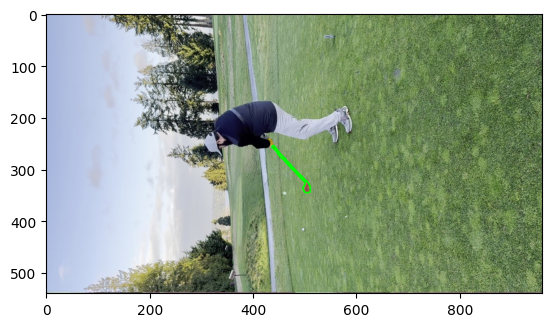

In [121]:
import cv2
import os

# Define the directory containing images
image_folder = 'path_to_images'
video_name = '/content/output_video.mp4'

# Get all image files from the directory and sort them
#images = [img for img in os.listdir(image_folder) if img.endswith(('.png', '.jpg', '.jpeg'))]
#images.sort()

# Read the first image to get dimensions
#first_image = cv2.imread(os.path.join(image_folder, images[0]))
height, width, layers = frame_sample[0].shape

# Define the codec and create VideoWriter object
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
video = cv2.VideoWriter(video_name, fourcc, 30, (width, height))
i = 0
# Loop through images and write them to the video
for image in frame_sample:
    # Draw the polygon on the image
    cv2.polylines(image, all_polygons[i], isClosed=True, color=(0, 255, 0), thickness=2)

    video.write(image)
    i = i + 1

# Release the video writer
video.release()
cv2.destroyAllWindows()

print(f'Video saved as {video_name}')



import matplotlib.pyplot as plt


# Show the image
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()
